# Projet - Modèle 1

Système proie-prédateur où les proies $V$ sont perturbées par un virus $X_t$ :
$$\mathrm{d}V_t = V_t\left(\tfrac23 - \tfrac43 P_t + X_t\right)\mathrm{d}t, \qquad \mathrm{d}P_t = P_t(-1 + V_t)\,\mathrm{d}t .$$
On cherche quel processus est $X_t$ (Q1.1), puis on étudie la probabilité d'extinction (Q1.2).

In [69]:
import numpy as np
import scipy.stats as scs
import matplotlib.pyplot as plt

## 1. Données et pas de temps

On charge `virus4.csv` (colonne 1 = victimes $V$, colonne 2 = prédateurs $P$).

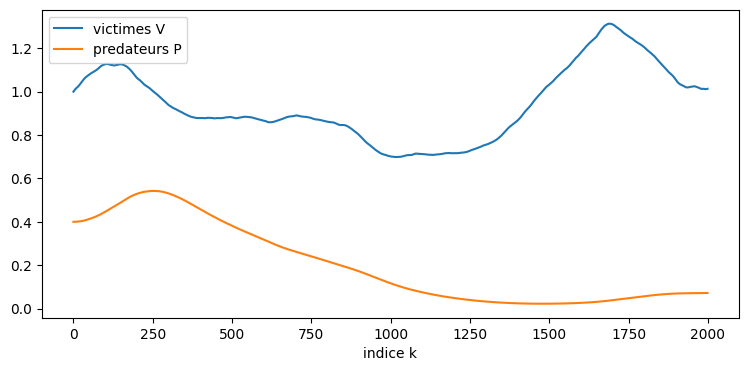

In [70]:
data = np.loadtxt('virus4.csv', delimiter=',')
V, P = data[:, 0], data[:, 1]
N = len(data)

plt.figure(figsize=(9, 4))
plt.plot(V, label='victimes V'); plt.plot(P, label='predateurs P')
plt.xlabel('indice k'); plt.legend(); plt.show()

L'équation des prédateurs est sans bruit, on en tire le pas de temps :
$$\Delta t = \frac{P_{k+1} - P_k}{P_k(V_k - 1)} .$$

In [71]:
num = P[1:] - P[:-1]; den = P[:-1] * (V[:-1] - 1); ok = np.abs(den) > 1e-3
dt = round(np.median(num[ok] / den[ok]), 3)
tau = N * dt
print('dt =', dt, '  tau =', tau)

dt = 0.015   tau = 30.0


## 2. Extraction du virus $X_t$

On inverse la première équation pour récupérer $X_t$ :
$$X_k = \frac{V_{k+1} - V_k}{V_k\,\Delta t} - \tfrac23 + \tfrac43 P_k .$$

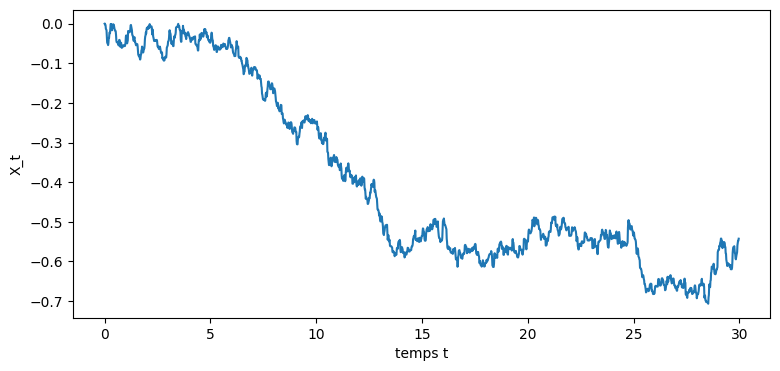

In [72]:
X = (V[1:] - V[:-1]) / (V[:-1] * dt) - 2/3 + 4/3 * P[:-1]
n = len(X)
t = np.arange(n) * dt

plt.figure(figsize=(9, 4))
plt.plot(t, X); plt.xlabel('temps t'); plt.ylabel('X_t'); plt.show()

In [73]:
# verification : on reinjecte X dans le schema d'Euler, on doit retrouver V exactement
Vrec = np.zeros(N); Vrec[0] = V[0]
for k in range(N - 1):
    Vrec[k+1] = Vrec[k] + Vrec[k] * (2/3 - 4/3 * P[k] + X[k]) * dt
print('erreur de reconstruction :', np.max(np.abs(Vrec - V)))

erreur de reconstruction : 0.0


Erreur nulle, l'extraction est donc exacte. $X$ reste borné entre $-0.7$ et $0$ et revient vers une valeur
négative : on cherche un processus à retour de moyenne.

## 3. Quel processus pour $X_t$ ?

$X$ est borné et revient vers une valeur, donc sa variance reste bornée. On regarde la variance de chaque
processus.

- **Mouvement brownien** : variance $t$, croît sans fin. Écarté.
- **Brownien avec dérive** : même variance qui croît. Écarté.
- **Brownien géométrique** : toujours positif, or $X$ est négatif. Écarté.
- **Pont brownien** : forcé de revenir à son point de départ à la fin. Écarté.
- **Mouvement brownien intégral** : variance $t^3/3$, croît encore plus vite. Écarté.
- **Ornstein-Uhlenbeck** : variance bornée vers $\frac{s^2}{2\gamma}$, retour de moyenne. Retenu.

Seul l'Ornstein-Uhlenbeck a une variance bornée, comme $X$.

In [74]:
# parametres de l'OU (ajustement AR(1)) et fonction de simulation des processus
x0, x1 = X[:-1], X[1:]
rho = np.cov(x0, x1, ddof=1)[0, 1] / np.var(x0, ddof=1)
m = (np.mean(x1) - rho * np.mean(x0)) / (1 - rho)
eps = x1 - (m + rho * (x0 - m))
gamma = -np.log(rho) / dt
s = np.std(eps, ddof=1) / np.sqrt((1 - rho**2) / (2 * gamma))

def simule(nom, rng):
    if nom == 'brownien':
        return X[0] + np.cumsum(s * np.sqrt(dt) * rng.standard_normal(n))
    if nom == 'brownien avec dérive':
        a = (X[-1] - X[0]) / tau
        return X[0] + a * t + np.cumsum(s * np.sqrt(dt) * rng.standard_normal(n))
    if nom == 'brownien integral':
        B = np.cumsum(s * np.sqrt(dt) * rng.standard_normal(n))
        return X[0] + np.cumsum(B) * dt
    if nom == 'Ornstein-Uhlenbeck':
        o = np.zeros(n)
        o[0] = X[0]
        r = np.exp(-gamma * dt)
        e = s * np.sqrt((1 - rho**2) / (2 * gamma))
        for k in range(1, n):
            o[k] = m + r * (o[k-1] - m) + e * rng.standard_normal()
        return o

Trois trajectoires simulées de chaque processus, avec $X$ en noir épais. Le brownien et l'intégral
s'échappent, le brownien avec dérive suit la tendance mais s'éparpille, et seul l'Ornstein-Uhlenbeck reste
groupé autour de $X$.

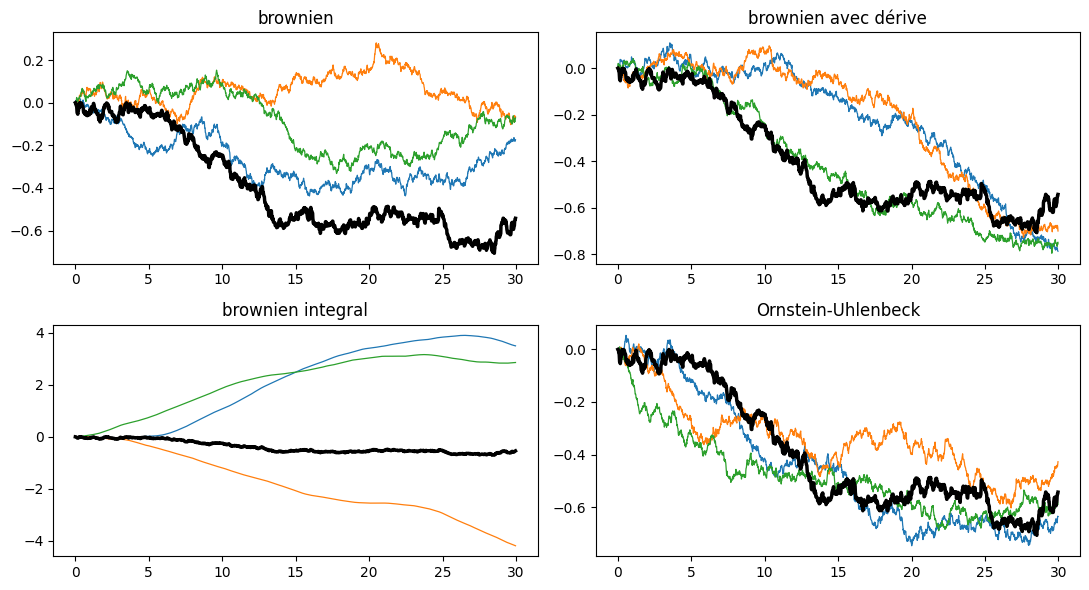

In [75]:
# trois simulations de chaque processus (couleur), X reel par-dessus (noir epais)
rng = np.random.default_rng(1)
fig, ax = plt.subplots(2, 2, figsize=(11, 6))
for a, nom in zip(ax.ravel(), ['brownien', 'brownien avec dérive', 'brownien integral', 'Ornstein-Uhlenbeck']):
    for _ in range(3):
        a.plot(t, simule(nom, rng), lw=0.9)
    a.plot(t, X, 'k', lw=2.5)
    a.set_title(nom)
plt.tight_layout()
plt.show()

## 4. Le modèle retenu : Ornstein-Uhlenbeck

$$\mathrm{d}X_t = -\gamma\,(X_t - m)\,\mathrm{d}t + s\,\mathrm{d}B_t ,$$
où $-\gamma(X_t - m)$ ramène vers la moyenne $m$. Paramètres ajustés ci-dessus.

In [76]:
print('gamma = %.3f   m = %.3f   s = %.3f' % (gamma, m, s))

gamma = 0.069   m = -0.657   s = 0.052


## 5. Validation : le bruit de l'OU

On regarde le bruit de l'OU, ses résidus. On trace leur histogramme et on teste leur loi par
Kolmogorov-Smirnov.

moyenne des residus = 0.0
KS contre une normale : p = 0.0


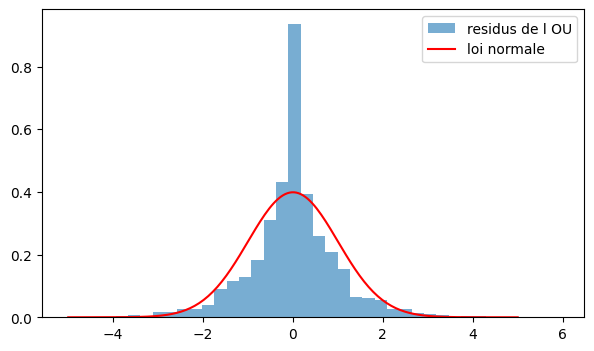

In [77]:
# les residus de l'OU sont son bruit. On teste leur loi
z = eps / np.std(eps, ddof=1)
print('moyenne des residus =', round(z.mean(), 3))
print('KS contre une normale : p =', round(scs.ks_1samp(z, scs.norm(0, 1).cdf).pvalue, 3))

xx = np.linspace(-5, 5, 200)
plt.figure(figsize=(7, 4))
plt.hist(z, bins=40, density=True, alpha=0.6, label='residus de l OU')
plt.plot(xx, scs.norm(0, 1).pdf(xx), 'r', label='loi normale')
plt.legend()
plt.show()

Les résidus sont centrés, donc l'OU capture la structure. Mais le KS rejette la loi normale et les queues
sont plus épaisses qu'une gaussienne : le bruit n'est pas tout à fait gaussien.

## 6. Limites

- Le KS sur les résidus rejette la gaussianité.
- Les résidus gardent une légère covariance ($0.26$).
- Une seule trajectoire, donc on ne prouve rien, on retient le meilleur modèle testé.

In [78]:
print('covariance des residus (lag 1) =', round(np.corrcoef(eps[:-1], eps[1:])[0, 1], 2))

covariance des residus (lag 1) = 0.26


## 7. Piste : un bruit à queues plus épaisses

Le bruit n'est pas gaussien. On regarde ses queues avec le moment d'ordre 4, qui vaut 3 pour une normale et
6 pour une Laplace.

In [79]:
# le bruit de l'OU, ce sont les residus eps. On regarde sa loi via le moment d'ordre 4.
z = eps / np.std(eps, ddof=1)
print('moment d ordre 4 du bruit =', round(np.mean(z**4), 2))
print('KS contre une normale : p =', round(scs.ks_1samp(z, scs.norm(0, 1).cdf).pvalue, 3))

moment d ordre 4 du bruit = 6.32
KS contre une normale : p = 0.0


In [80]:
# OU a bruit gaussien vs bruit de Laplace : lequel reproduit le moment d'ordre 4 des donnees ?
sige = np.std(eps, ddof=1)
bL = sige / np.sqrt(2)

def moment4_bruit(bruit, K=200):
    rng = np.random.default_rng(0)
    vals = []
    for _ in range(K):
        o = np.zeros(n)
        o[0] = X[0]
        for k in range(1, n):
            o[k] = m + rho * (o[k-1] - m) + bruit(rng)
        e = o[1:] - (m + rho * (o[:-1] - m))    # le bruit injecte (residu de l'OU)
        e = e / np.std(e, ddof=1)
        vals.append(np.mean(e**4))
    return np.mean(vals)

print('moment d ordre 4 cible =', round(np.mean(z**4), 2))
print('OU bruit gaussien =', round(moment4_bruit(lambda r: sige * r.standard_normal()), 2))
print('OU bruit de Laplace =', round(moment4_bruit(lambda r: r.laplace(0, bL)), 2))

moment d ordre 4 cible = 6.32
OU bruit gaussien = 3.0
OU bruit de Laplace = 6.04


Le moment d'ordre 4 du bruit vaut environ $6.3$, loin du $3$ d'une normale, proche du $6$ d'une Laplace. Un
OU à bruit de Laplace retrouve ce $6$, un bruit gaussien reste à $3$. Un modèle plus fidèle serait donc un OU
à bruit de Laplace. C'est une piste en plus, au-delà du modèle gaussien.

## 8. Probabilité d'extinction (Q1.2)

Une population est éteinte au premier instant où $V_t \le 0.01$ ou $P_t \le 0.01$, un temps d'arrêt. On simule
beaucoup de trajectoires avec l'OU.

In [81]:
seuil = 0.01

def simule_VP(rng):
    Vs = np.zeros(N)
    Ps = np.zeros(N)
    Xs = np.zeros(N)
    Vs[0], Ps[0], Xs[0] = V[0], P[0], X[0]
    r = np.exp(-gamma * dt)
    e = s * np.sqrt((1 - rho**2) / (2 * gamma))
    for k in range(N - 1):
        Xs[k+1] = m + r * (Xs[k] - m) + e * rng.standard_normal()
        Vs[k+1] = Vs[k] + Vs[k] * (2/3 - 4/3 * Ps[k] + Xs[k]) * dt
        Ps[k+1] = Ps[k] + Ps[k] * (-1 + Vs[k]) * dt
    return Vs, Ps

rng = np.random.default_rng(0)
nV = 0
nP = 0
for _ in range(2000):
    Vs, Ps = simule_VP(rng)
    nV += np.any(Vs <= seuil)
    nP += np.any(Ps <= seuil)
print('P(extinction victimes) =', nV / 2000)
print('P(extinction predateurs) =', nP / 2000)

P(extinction victimes) = 0.0015
P(extinction predateurs) = 0.3415


Les victimes ne s'éteignent presque jamais. On regarde la loi du temps d'extinction des prédateurs, sur un
horizon plus long.

Gamma par methode des moments : forme k = 2.89, echelle = 10.03, decalage = 10.4
KS loi gamma : p = 0.325
P(extinction avant tau=30) = 0.335


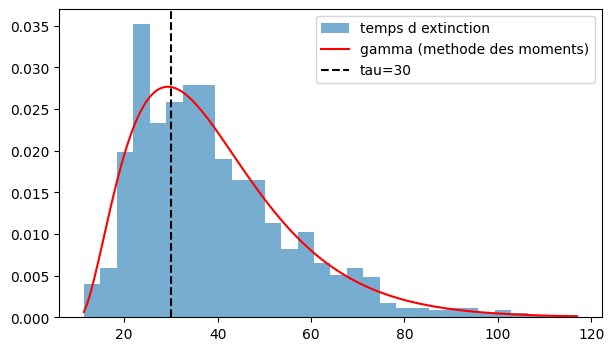

In [82]:
def temps_extinction_P(rng, npas):
    Vk, Pk, Xk = V[0], P[0], X[0]
    r = np.exp(-gamma * dt); e = s * np.sqrt((1 - rho**2) / (2 * gamma))
    for k in range(1, npas):
        Xk = m + r * (Xk - m) + e * rng.standard_normal()
        Vk = Vk + Vk * (2/3 - 4/3 * Pk + Xk) * dt
        Pk = Pk + Pk * (-1 + Vk) * dt
        if Pk <= seuil:
            return k * dt
    return -1

rng = np.random.default_rng(7)
T = []
for _ in range(1000):
    tt = temps_extinction_P(rng, int(120 / dt))
    if tt > 0:
        T.append(tt)
T = np.array(T)

# loi Gamma estimee par la METHODE DES MOMENTS. Il y a un delai minimal avant extinction, on decale.
decalage = T.min() - 1
Td = T - decalage
mu = Td.mean(); var = Td.var(ddof=1)        # moyenne et variance (les moments)
k = mu**2 / var                              # forme :  moyenne = k*theta,  variance = k*theta^2
theta = var / mu                             # echelle
print('Gamma par methode des moments : forme k = %.2f, echelle = %.2f, decalage = %.1f' % (k, theta, decalage))

loi = scs.gamma(a=k, loc=decalage, scale=theta)   # scs.gamma sert juste a evaluer la densite
print('KS loi gamma : p =', round(scs.kstest(T, loi.cdf).pvalue, 3))
print('P(extinction avant tau=30) =', np.mean(T <= 30))

xx = np.linspace(T.min(), T.max(), 200)
plt.figure(figsize=(7, 4))
plt.hist(T, bins=30, density=True, alpha=0.6, label='temps d extinction')
plt.plot(xx, loi.pdf(xx), 'r', label='gamma (methode des moments)')
plt.axvline(30, color='k', ls='--', label='tau=30'); plt.legend(); plt.show()

On propose une loi **Gamma** pour le temps d'extinction. On estime ses paramètres par la méthode des
moments, après un décalage pour le délai minimal avant extinction. Le KS ne la rejette pas. La probabilité
d'extinction sur la fenêtre vaut environ $0.34$.

## Conclusion du modèle 1

On a extrait $X_t$, écarté les processus dont la variance explose, et gardé l'Ornstein-Uhlenbeck, le seul
borné comme les données. On l'a validé par ses résidus, centrés mais à queues plus épaisses qu'une
gaussienne. Les victimes ne s'éteignent presque jamais, le temps d'extinction des prédateurs suit une loi
gamma. Enfin, le bruit de $X_t$ est plutôt de type Laplace, ce qui ouvre vers un modèle plus fin.

## Annexe : résidus standardisés

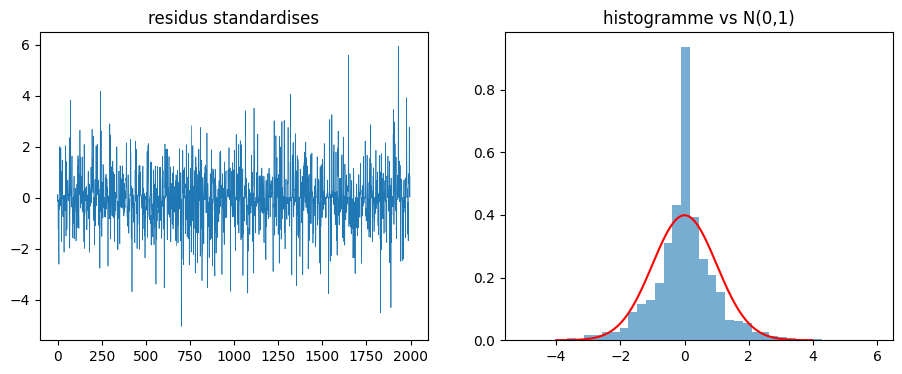

In [83]:
z = eps / np.std(eps, ddof=1)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(z, lw=0.5); ax[0].set_title('residus standardises')
ax[1].hist(z, bins=40, density=True, alpha=0.6)
xx = np.linspace(-4, 4, 200); ax[1].plot(xx, scs.norm(0,1).pdf(xx), 'r')
ax[1].set_title('histogramme vs N(0,1)'); plt.show()